In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data= pd.read_csv("netflix_org_data.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
data.shape

(8807, 12)

In [ ]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
(data == "").sum() #checking for empty data cell


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Director,Cast,Country have major null values otherwise rating, date_added and Duration have 2,3 null valuyes only so we drop these 2,3 rows

In [ ]:
data[data["date_added"].isna()]



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [ ]:
data[data["country"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8718,s8719,Movie,Westside vs. the World,Michael Fahey,"Ron Perlman, Louie Simmons",NaN,"August 9, 2019",2019,TV-MA,96 min,"Documentaries, Sports Movies",A look into the journey of influential strengt...
8759,s8760,Movie,World's Weirdest Homes,Storm Theunissen,Charlie Luxton,NaN,"February 1, 2019",2015,TV-PG,49 min,Movies,From a bubble-shaped palace to an island built...
8783,s8784,TV Show,Yoko,NaN,"Eileen Stevens, Alyson Leigh Rosenfeld, Sarah ...",NaN,"June 23, 2018",2016,TV-Y,1 Season,Kids' TV,"Friends Mai, Oto and Vik's games at the park b..."
8785,s8786,TV Show,YOM,NaN,"Sairaj, Devyani Dagaonkar, Ketan Singh, Mayur ...",NaN,"June 7, 2018",2016,TV-Y7,1 Season,Kids' TV,"With the mind of a human being, and the body o..."


In [ ]:
data[data["director"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


In [ ]:
data[data["cast"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
...,...,...,...,...,...,...,...,...,...,...,...,...
8746,s8747,Movie,Winnie,Pascale Lamche,NaN,"France, Netherlands, South Africa, Finland","February 26, 2018",2017,TV-14,85 min,"Documentaries, International Movies",Winnie Mandela speaks about her extraordinary ...
8755,s8756,TV Show,Women Behind Bars,NaN,NaN,United States,"November 1, 2016",2010,TV-14,3 Seasons,"Crime TV Shows, Docuseries",This reality series recounts true stories of w...
8756,s8757,Movie,Woodstock,Barak Goodman,NaN,United States,"August 13, 2019",2019,TV-MA,97 min,"Documentaries, Music & Musicals",For the 50th anniversary of the legendary Wood...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...


In [ ]:
rating_na=data[data["rating"].isnull()]
rating_na

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [ ]:
rating_na.index

Index([5989, 6827, 7312, 7537], dtype='int64')

we need to drop these indexed rating rows




In [ ]:
data["show_id"].nunique()

8807

we checked that all the show ids are unique which helps us to identify each rows uniquely,like index number of data.

In [ ]:
data.dropna(subset=['rating'],inplace=True)

In [ ]:
# data.drop(index=[5989, 6827, 7312, 7537],axis=0,inplace=True)

In [ ]:
# data=data[data["show_id"].isin(rating_na["show_id"])].dropna()
# data

In [ ]:
duration_na=data[data['duration'].isnull()]
duration_na

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [ ]:
duration_na.index

Index([5541, 5794, 5813], dtype='int64')

In [ ]:
data.drop(index=[5541, 5794, 5813],inplace=True)

In [ ]:
date_na=data[data['date_added'].isna()]
date_na

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [ ]:
date_na.index

Index([6066, 6174, 6795, 6806, 6901, 7196, 7254, 7406, 7847, 8182], dtype='int64')

In [ ]:
data.drop(index=[6066, 6174, 6795, 6806, 6901, 7196, 7254, 7406, 7847, 8182],inplace=True)

In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
director,2621
cast,825
country,829
date_added,0
release_year,0
rating,0
duration,0


now we need to take care of null values for director,cast,country column


In [ ]:
# (data=="").sum()

In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
director,2621
cast,825
country,829
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
# data.head(30)

In [ ]:
data[data==""].sum()#checking blank strings/cell

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0.0
rating,0
duration,0


In [ ]:
data["director"].fillna("Unknown", inplace=True)
data["cast"].fillna("Unknown", inplace=True)
data["country"].fillna("Unknown", inplace=True)
#here we have put a place holder for nan,null

/tmp/ipython-input-2734571126.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["director"].fillna("Unknown", inplace=True)
/tmp/ipython-input-2734571126.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
# data.isna().sum()

# now we have successfully removed nan,null values

In [ ]:
# data.head(3) #someofthing we need to take care of is director ,cast,country.listed_in need to seperated for each individula ot get more detailed insights

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 892.7+ KB


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
listed_in=data["listed_in"].str.split(",").tolist()
# listed_in

[['Documentaries'],
 ['International TV Shows', ' TV Dramas', ' TV Mysteries'],
 ['Crime TV Shows', ' International TV Shows', ' TV Action & Adventure'],
 ['Docuseries', ' Reality TV'],
 ['International TV Shows', ' Romantic TV Shows', ' TV Comedies'],
 ['TV Dramas', ' TV Horror', ' TV Mysteries'],
 ['Children & Family Movies'],
 ['Dramas', ' Independent Movies', ' International Movies'],
 ['British TV Shows', ' Reality TV'],
 ['Comedies', ' Dramas'],
 ['Crime TV Shows', ' Docuseries', ' International TV Shows'],
 ['Crime TV Shows', ' International TV Shows', ' TV Action & Adventure'],
 ['Dramas', ' International Movies'],
 ['Children & Family Movies', ' Comedies'],
 ['British TV Shows', ' Crime TV Shows', ' Docuseries'],
 ['TV Comedies', ' TV Dramas'],
 ['Documentaries', ' International Movies'],
 ['Crime TV Shows', ' Spanish-Language TV Shows', ' TV Dramas'],
 ['Thrillers'],
 ['International TV Shows',
  ' Spanish-Language TV Shows',
  ' TV Action & Adventure'],
 ['Crime TV Shows', '

In [ ]:
listed_in_data=pd.DataFrame(listed_in,index=data["title"]).stack().reset_index().drop("level_1",axis=1).rename({0:"listed_in"},axis=1)
# listed_in_data

,title,listed_in
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,International TV Shows
2,Blood & Water,TV Dramas
3,Blood & Water,TV Mysteries
4,Ganglands,Crime TV Shows
...,...,...
19289,Zoom,Children & Family Movies
19290,Zoom,Comedies
19291,Zubaan,Dramas
19292,Zubaan,International Movies


In [ ]:
listed_in_data["listed_in"] = listed_in_data["listed_in"].str.strip()


In [ ]:
(listed_in_data=="").sum()

,0
title,0
listed_in,0


In [ ]:
# data["cast"].str.split(",").tolist()

In [ ]:
# data["cast"]=data["cast"].str.split(",").tolist()
# data.head(30)

In [ ]:
# cast=data["cast"].apply(lambda x:str(x).split(",") ).tolist()
# cast[5]

In [ ]:
# data.shape

In [ ]:
cast=data["cast"].str.split(",").tolist()
cast

[['Unknown'],
 ['Ama Qamata',
  ' Khosi Ngema',
  ' Gail Mabalane',
  ' Thabang Molaba',
  ' Dillon Windvogel',
  ' Natasha Thahane',
  ' Arno Greeff',
  ' Xolile Tshabalala',
  ' Getmore Sithole',
  ' Cindy Mahlangu',
  ' Ryle De Morny',
  ' Greteli Fincham',
  ' Sello Maake Ka-Ncube',
  ' Odwa Gwanya',
  ' Mekaila Mathys',
  ' Sandi Schultz',
  ' Duane Williams',
  ' Shamilla Miller',
  ' Patrick Mofokeng'],
 ['Sami Bouajila',
  ' Tracy Gotoas',
  ' Samuel Jouy',
  ' Nabiha Akkari',
  ' Sofia Lesaffre',
  ' Salim Kechiouche',
  ' Noureddine Farihi',
  ' Geert Van Rampelberg',
  ' Bakary Diombera'],
 ['Unknown'],
 ['Mayur More',
  ' Jitendra Kumar',
  ' Ranjan Raj',
  ' Alam Khan',
  ' Ahsaas Channa',
  ' Revathi Pillai',
  ' Urvi Singh',
  ' Arun Kumar'],
 ['Kate Siegel',
  ' Zach Gilford',
  ' Hamish Linklater',
  ' Henry Thomas',
  ' Kristin Lehman',
  ' Samantha Sloyan',
  ' Igby Rigney',
  ' Rahul Kohli',
  ' Annarah Cymone',
  ' Annabeth Gish',
  ' Alex Essoe',
  ' Rahul Abburi'

In [ ]:
cast_data=pd.DataFrame(cast,index=data["title"]).stack().reset_index().drop("level_1",axis=1).rename({0:"cast"},axis=1)
cast_data["cast"]=cast_data["cast"].str.strip()

In [ ]:
(cast_data=="").sum()

,0
title,0
cast,0


In [ ]:
cast_data

,title,cast
0,Dick Johnson Is Dead,Unknown
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
64836,Zubaan,Manish Chaudhary
64837,Zubaan,Meghna Malik
64838,Zubaan,Malkeet Rauni
64839,Zubaan,Anita Shabdish


In [ ]:
# data.isna().sum()

In [ ]:
country= data["country"].str.split(",").tolist()

In [ ]:
data_country = pd.DataFrame(country,index=data["title"]).stack().reset_index().drop("level_1",axis=1).rename({0:"country"},axis=1)
# data_country["country"]=data_country["country"].str.strip()
data_country["country"] = data_country["country"].replace("", "unknown")


In [ ]:
(data_country=="").sum()

,0
title,0
country,0


In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
data_country

,title,country
0,Dick Johnson Is Dead,United States
1,Blood & Water,South Africa
2,Ganglands,Unknown
3,Jailbirds New Orleans,Unknown
4,Kota Factory,India
...,...,...
10828,Zodiac,United States
10829,Zombie Dumb,Unknown
10830,Zombieland,United States
10831,Zoom,United States


In [ ]:
# data.isna().sum()

In [ ]:
director= data["director"].str.split(",").tolist()
director

[['Kirsten Johnson'],
 ['Unknown'],
 ['Julien Leclercq'],
 ['Unknown'],
 ['Unknown'],
 ['Mike Flanagan'],
 ['Robert Cullen', ' José Luis Ucha'],
 ['Haile Gerima'],
 ['Andy Devonshire'],
 ['Theodore Melfi'],
 ['Unknown'],
 ['Kongkiat Komesiri'],
 ['Christian Schwochow'],
 ['Bruno Garotti'],
 ['Unknown'],
 ['Unknown'],
 ['Pedro de Echave García', ' Pablo Azorín Williams'],
 ['Unknown'],
 ['Adam Salky'],
 ['Unknown'],
 ['Olivier Megaton'],
 ['Unknown'],
 ['K.S. Ravikumar'],
 ['Alex Woo', ' Stanley Moore'],
 ['S. Shankar'],
 ['Unknown'],
 ['Rajiv Menon'],
 ['Dennis Dugan'],
 ['Scott Stewart'],
 ['Robert Luketic'],
 ['Ashwiny Iyer Tiwari', ' Abhishek Chaubey', ' Saket Chaudhary'],
 ['Unknown'],
 ['Unknown'],
 ['Unknown'],
 ['Unknown'],
 ['Daniel Sandu'],
 ['Cédric Jimenez'],
 ['Unknown'],
 ['George Nolfi'],
 ['Unknown'],
 ['Unknown'],
 ['Steven Spielberg'],
 ['Jeannot Szwarc'],
 ['Joe Alves'],
 ['Joseph Sargent'],
 ['Tyler Greco'],
 ['Daniel Espinosa'],
 ['Bunmi Ajakaiye'],
 ['Antoine Fuqua

In [ ]:
director_data= pd.DataFrame(director,data["title"]).stack().reset_index().drop("level_1",axis=1).rename({0:"director"},axis=1)
director_data["director"]=director_data["director"].str.strip()

In [ ]:
director_data

,title,director
0,Dick Johnson Is Dead,Kirsten Johnson
1,Blood & Water,Unknown
2,Ganglands,Julien Leclercq
3,Jailbirds New Orleans,Unknown
4,Kota Factory,Unknown
...,...,...
9590,Zodiac,David Fincher
9591,Zombie Dumb,Unknown
9592,Zombieland,Ruben Fleischer
9593,Zoom,Peter Hewitt


In [ ]:
data.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


now our challeneg to prepare the data is speaerate date added into months ,year,date it will be helpfull in analysis,

In [ ]:
# month = data['date_added'].str.split(" ").tolist()
# month

In [ ]:
data["date_added"] = data["date_added"].str.strip()


In [ ]:
date_split = data['date_added'].str.split(" ", expand=True)
date_split

,0,1,2
0,September,"25,",2021
1,September,"24,",2021
2,September,"24,",2021
3,September,"24,",2021
4,September,"24,",2021
...,...,...,...
8802,November,"20,",2019
8803,July,"1,",2019
8804,November,"1,",2019
8805,January,"11,",2020


In [ ]:
data["month_added"] = date_split[0].str.strip()
data["day_added"]   = date_split[1].str.replace(",","").str.strip()
data["year_added"]  = date_split[2].str.strip()


In [ ]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,day_added,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,25,2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,24,2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,24,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,24,2021
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,24,2021


In [ ]:
# data.shape

In [ ]:
data["type"].value_counts()

,count
type,
Movie,6126
TV Show,2664


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
 12  month_added   8790 non-null   object
 13  day_added     8790 non-null   object
 14  year_added    8790 non-null   object
dtypes: int64(1), object(14)
memory usage: 1.3+ MB


In [ ]:
data["Seasons"]=data[data["type"]=="TV Show"]["duration"].str.split(" ",expand=True)[0]
data["Seasons"]=data["Seasons"].str.strip()

In [ ]:
data["minutes"]=data[data["type"]=="Movie"]["duration"].str.split(" ",expand=True)[0]
data["minutes"]=data["minutes"].str.strip()

 remeber till now we have not merged our **director,cast,country and listed_in** data  so shape is same as orginal data.

In [ ]:
data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,day_added,year_added,Seasons,minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,25,2021,NaN,90
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",September,24,2021,2,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,September,24,2021,1,NaN
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",September,24,2021,1,NaN
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,September,24,2021,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",November,20,2019,NaN,158
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",July,1,2019,2,NaN
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,November,1,2019,NaN,88
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",January,11,2020,NaN,88


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
 12  month_added   8790 non-null   object
 13  day_added     8790 non-null   object
 14  year_added    8790 non-null   object
 15  Seasons       2664 non-null   object
 16  minutes       6126 non-null   object
dtypes: int64(1), object(16)
memory usage: 1.5+ MB


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
# data[data["month_added"]==""]

In [ ]:
data["rating"].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


In [ ]:
data=data.drop(["director","cast","country","description","listed_in","date_added"],axis=1)
data.head(10)

,show_id,type,title,release_year,rating,duration,month_added,day_added,year_added,Seasons,minutes
0,s1,Movie,Dick Johnson Is Dead,2020,PG-13,90 min,September,25,2021,NaN,90
1,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN
2,s3,TV Show,Ganglands,2021,TV-MA,1 Season,September,24,2021,1,NaN
3,s4,TV Show,Jailbirds New Orleans,2021,TV-MA,1 Season,September,24,2021,1,NaN
4,s5,TV Show,Kota Factory,2021,TV-MA,2 Seasons,September,24,2021,2,NaN
5,s6,TV Show,Midnight Mass,2021,TV-MA,1 Season,September,24,2021,1,NaN
6,s7,Movie,My Little Pony: A New Generation,2021,PG,91 min,September,24,2021,NaN,91
7,s8,Movie,Sankofa,1993,TV-MA,125 min,September,24,2021,NaN,125
8,s9,TV Show,The Great British Baking Show,2021,TV-14,9 Seasons,September,24,2021,9,NaN
9,s10,Movie,The Starling,2021,PG-13,104 min,September,24,2021,NaN,104


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


In [ ]:
data.shape

(8790, 11)

In [ ]:
data=data.merge(cast_data,how="inner",on="title")
data

,show_id,type,title,release_year,rating,duration,month_added,day_added,year_added,Seasons,minutes,cast
0,s1,Movie,Dick Johnson Is Dead,2020,PG-13,90 min,September,25,2021,NaN,90,Unknown
1,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata
2,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Khosi Ngema
3,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Gail Mabalane
4,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Thabang Molaba
...,...,...,...,...,...,...,...,...,...,...,...,...
64836,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Manish Chaudhary
64837,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Meghna Malik
64838,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Malkeet Rauni
64839,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Anita Shabdish


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


In [ ]:
data=data.merge(director_data,how="inner",on="title")
data

,show_id,type,title,release_year,rating,duration,month_added,day_added,year_added,Seasons,minutes,cast,director
0,s1,Movie,Dick Johnson Is Dead,2020,PG-13,90 min,September,25,2021,NaN,90,Unknown,Kirsten Johnson
1,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown
2,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Khosi Ngema,Unknown
3,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Gail Mabalane,Unknown
4,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Thabang Molaba,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70697,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Manish Chaudhary,Mozez Singh
70698,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Meghna Malik,Mozez Singh
70699,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Malkeet Rauni,Mozez Singh
70700,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Anita Shabdish,Mozez Singh


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,50086


In [ ]:
data=data.merge(data_country,how="inner",on="title")
data

,show_id,type,title,release_year,rating,duration,month_added,day_added,year_added,Seasons,minutes,cast,director,country
0,s1,Movie,Dick Johnson Is Dead,2020,PG-13,90 min,September,25,2021,NaN,90,Unknown,Kirsten Johnson,United States
1,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown,South Africa
2,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Khosi Ngema,Unknown,South Africa
3,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Gail Mabalane,Unknown,South Africa
4,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Thabang Molaba,Unknown,South Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89300,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Manish Chaudhary,Mozez Singh,India
89301,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Meghna Malik,Mozez Singh,India
89302,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Malkeet Rauni,Mozez Singh,India
89303,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Anita Shabdish,Mozez Singh,India


In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,65367


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


In [ ]:
data=data.merge(listed_in_data,how="inner",on="title")
data

,show_id,type,title,release_year,rating,duration,month_added,day_added,year_added,Seasons,minutes,cast,director,country,listed_in
0,s1,Movie,Dick Johnson Is Dead,2020,PG-13,90 min,September,25,2021,NaN,90,Unknown,Kirsten Johnson,United States,Documentaries
1,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown,South Africa,International TV Shows
2,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown,South Africa,TV Dramas
3,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown,South Africa,TV Mysteries
4,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Khosi Ngema,Unknown,South Africa,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201832,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Anita Shabdish,Mozez Singh,India,International Movies
201833,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Anita Shabdish,Mozez Singh,India,Music & Musicals
201834,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Chittaranjan Tripathy,Mozez Singh,India,Dramas
201835,s8807,Movie,Zubaan,2015,TV-14,111 min,March,2,2019,NaN,111,Chittaranjan Tripathy,Mozez Singh,India,International Movies


now we need to settle NAN/null check for empty strings and duplicates

In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,145905


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


we have created minutes and seasons and these two only contains Null

In [ ]:
# data.duplicated().sum()

In [ ]:
# data.drop_duplicates(inplace=True)



In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


In [ ]:
data["country"] = data["country"].replace("", np.nan)


In [ ]:
(data=="").sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,0


In [ ]:
data.isna().sum()

,0
show_id,0
type,0
title,0
release_year,0
rating,0
duration,0
month_added,0
day_added,0
year_added,0
Seasons,145905


In [ ]:
data.head()

,show_id,type,title,release_year,rating,duration,month_added,day_added,year_added,Seasons,minutes,cast,director,country,listed_in
0,s1,Movie,Dick Johnson Is Dead,2020,PG-13,90 min,September,25,2021,NaN,90,Unknown,Kirsten Johnson,United States,Documentaries
1,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown,South Africa,International TV Shows
2,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown,South Africa,TV Dramas
3,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Ama Qamata,Unknown,South Africa,TV Mysteries
4,s2,TV Show,Blood & Water,2021,TV-MA,2 Seasons,September,24,2021,2,NaN,Khosi Ngema,Unknown,South Africa,International TV Shows


now our data is good to start analysis

In [ ]:
movies_num= data[data["type"]=="Movie"]["release_year"].value_counts()
TV_Show_num= data[data["type"]=="TV Show"]["release_year"].value_counts()
movies_num = movies_num.sort_index()

In [ ]:
release_year= data["release_year"].value_counts()


In [ ]:
# plt.figure(figsize=(18,10))
# plt.title("Number of realease per year")
# sns.barplot(x=release_year.index, y=release_year)
# plt.xticks(rotation=90)
# plt.show()

In [ ]:
# plt.figure(figsize=(18,6))
# plt.bar(x=movies_num.index,height=movies_num.values)
# plt.title("Number of Movies realeased per year")
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(18,6))
# sns.countplot(x="release_year",data=data[data["type"] == "Movie"])
# plt.title("Number of Movies realeased per year")
# plt.xticks(rotation=90)
# plt.show()

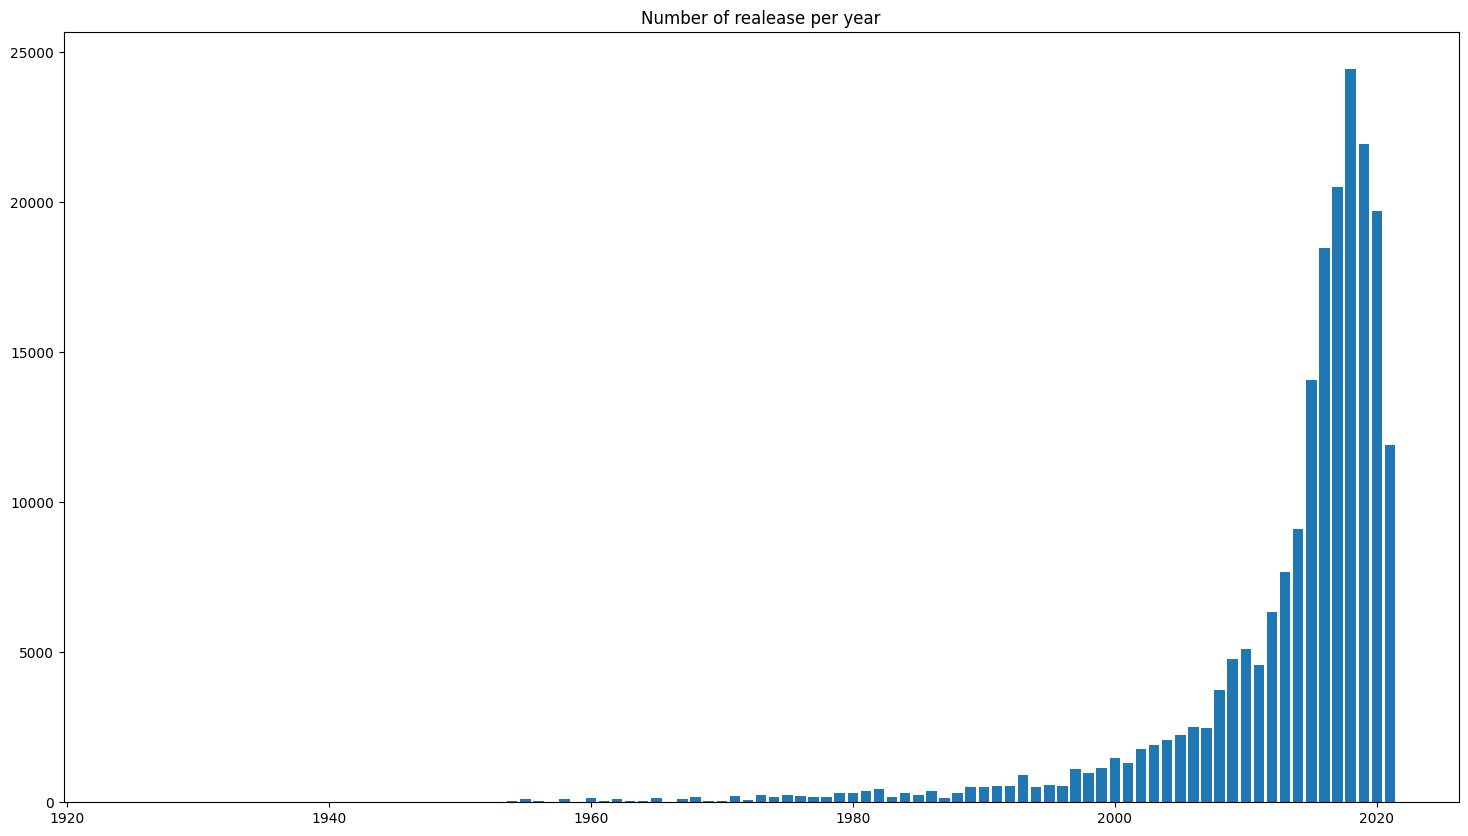

In [ ]:
plt.figure(figsize=(18,10))
plt.bar(x=release_year.index,height= release_year)
plt.title("Number of realease per year")
plt.show()

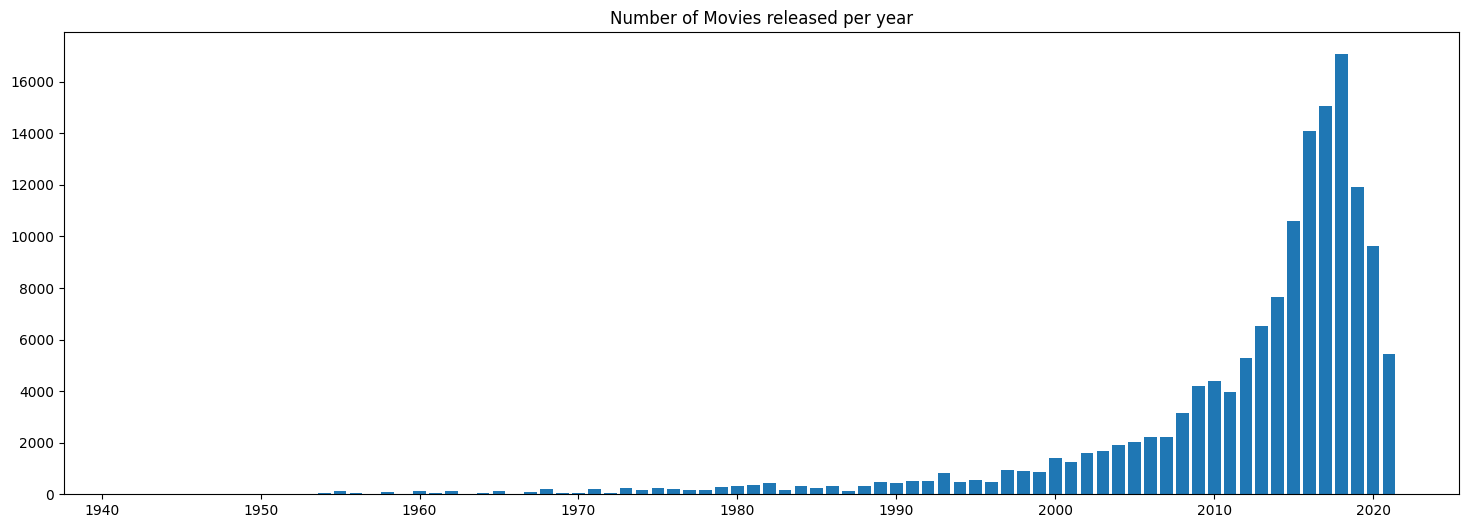

In [ ]:
plt.figure(figsize=(18,6))
plt.bar(x=movies_num.index, height=movies_num.values)
plt.title("Number of Movies released per year")
plt.show()

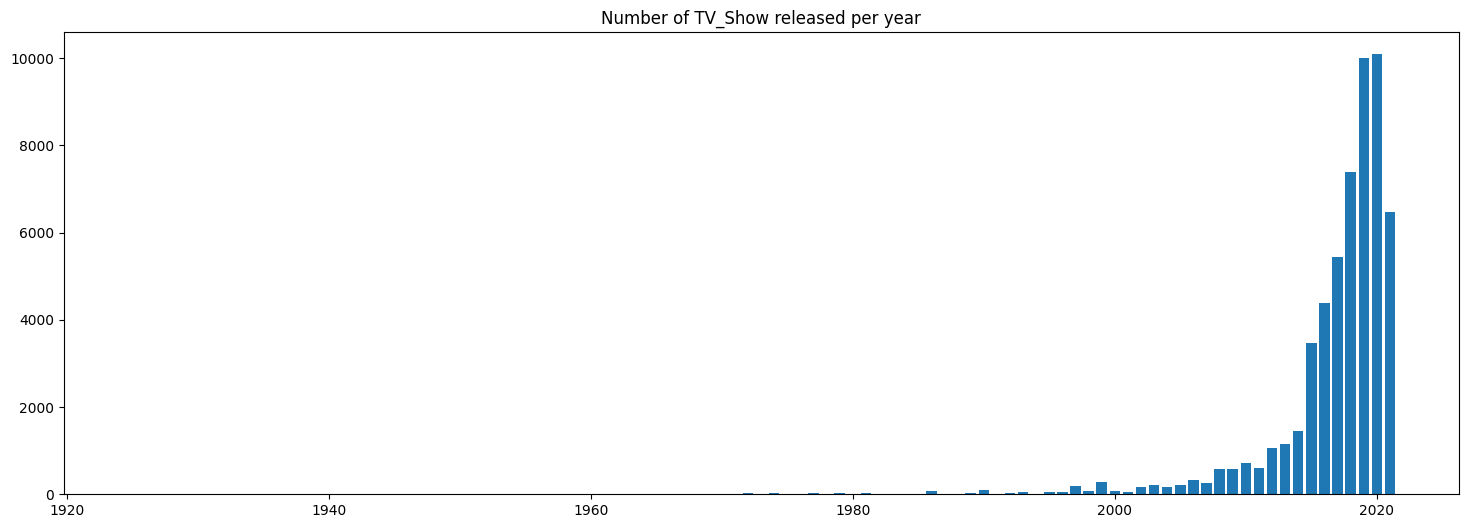

In [ ]:
plt.figure(figsize=(18,6))
plt.bar(x=TV_Show_num.index, height=TV_Show_num.values)
plt.title("Number of TV_Show released per year")
plt.show()

Our charts,shows three major phases:

1. Slow Growth Era (1920–2000)

    Very few movies and almost no TV shows.

    Production was limited by technology, distribution, and regional restrictions.

2. Digital Expansion Era (2000–2010)

    Production increases significantly.

    Cheaper cameras + internet distribution helped global content creation.

    Movies grow faster than TV shows.

3. Streaming Boom (2010–2020) — The big jump

    This is where the charts explode upward for all categories.

Why?

    Production becomes global (Korea, India, Turkey, Spain, etc.).

    Both movies and TV shows rise sharply.

    Peak: 2018–2020

    Over 20,000 total releases in a year.

    Movies ~16k & TV shows ~10k.

    This is the fastest growth period in film/TV history.

4. Post-2020 Decline (Pandemic Effects)

    COVID halted production.

    Companies reduced budgets in 2021–2023.

    Streaming market saturation slowed new releases.

In [ ]:
Top_10_cast= data["cast"].value_counts().sort_values(ascending=False).head(11)
Top_10_cast = Top_10_cast.iloc[1:11]

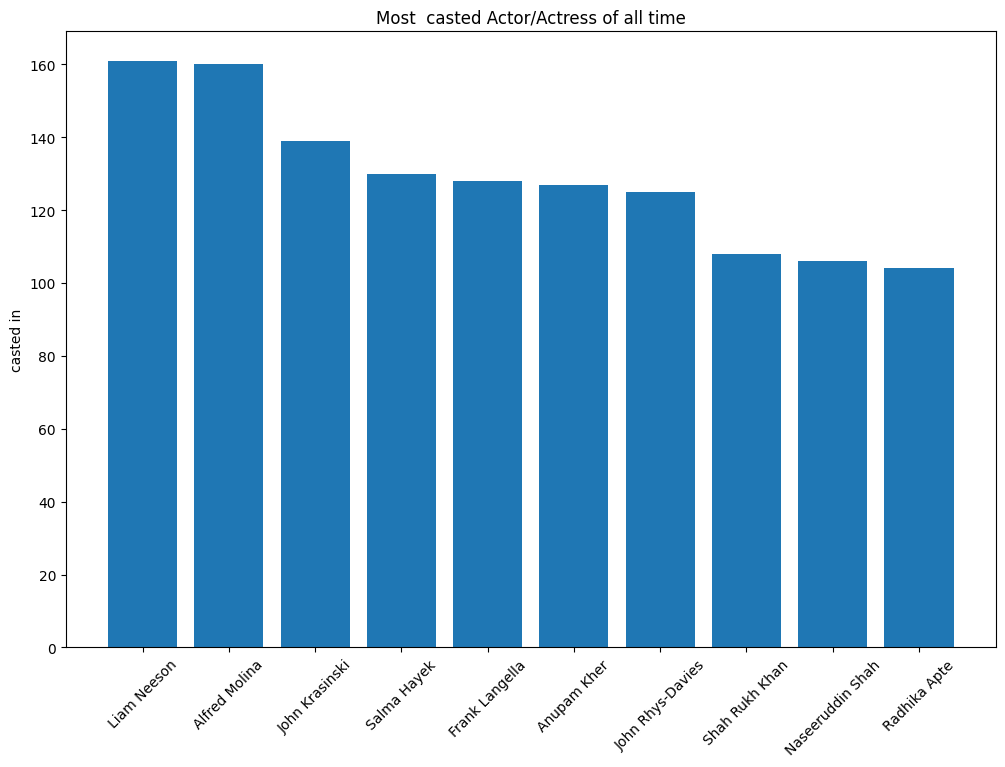

In [ ]:
plt.figure(figsize=(12,8))
plt.bar(x=Top_10_cast.index,height=Top_10_cast.values)
plt.xticks(rotation =45)
plt.ylabel("casted in")
plt.title("Most  casted Actor/Actress of all time")
plt.show()

In [ ]:
unique_movies = data.groupby("director")["title"].nunique()
unique_years = data.groupby("director")["release_year"].nunique()

director_prod = pd.DataFrame({
    "unique_movies": unique_movies,
    "unique_years": unique_years
})
# director_prod


,unique_movies,unique_years
director,,
A. L. Vijay,2,2
A. Raajdheep,1,1
A. Salaam,1,1
A.R. Murugadoss,2,2
Aadish Keluskar,1,1
...,...,...
Éric Warin,1,1
Ísold Uggadóttir,1,1
Óskar Thór Axelsson,1,1


let's understand the duration of movies and season for tv show

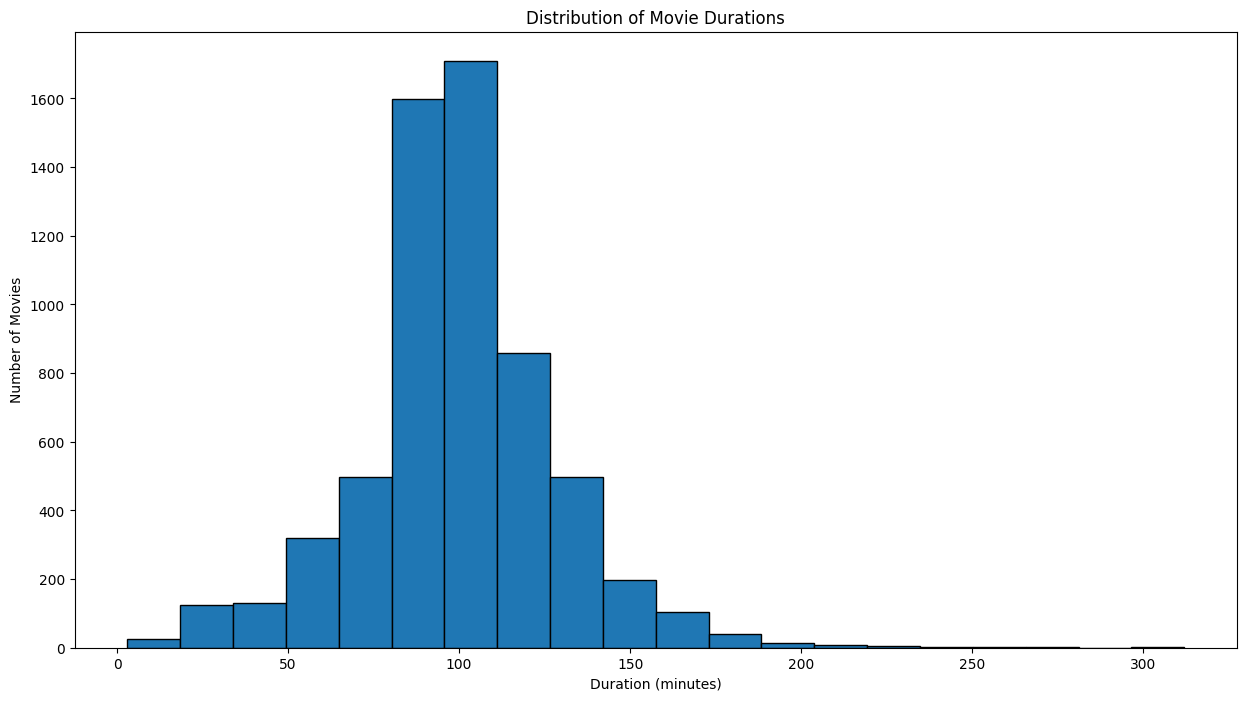

In [ ]:
movie_min = data[data["type"]=="Movie"][["title","minutes"]].drop_duplicates()
movie_min["minutes"] = pd.to_numeric(movie_min["minutes"], errors="coerce")
pd.cut(movie_min["minutes"], bins=10)
plt.figure(figsize=(15,8))
plt.hist(movie_min["minutes"], bins=20,edgecolor="black")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Durations")
plt.show()


1. Most movies are between ~80 and 120 minutes
2. The distribution is bell-shaped but slightly right-skewed
3. Very short movies (<50 min) are uncommon
These could be: documentaries, kids content, short films mistakenly tagged as movies
4. Very long movies (>180 min) almost disappear

The small bars after 180 minutes show only a tiny number of films go beyond 3 hours.

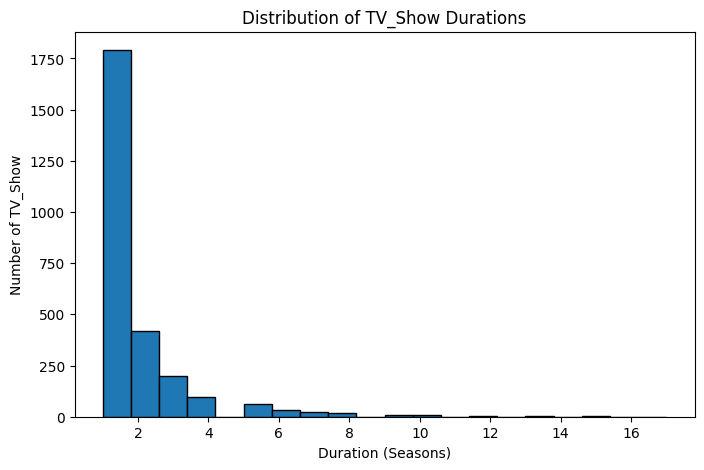

In [ ]:
TV_Show = data[data["type"]=="TV Show"][["title","Seasons"]].drop_duplicates()
# TV_Show

TV_Show["Seasons"] = pd.to_numeric(TV_Show["Seasons"], errors="coerce")
pd.cut(TV_Show["Seasons"], bins=5)
plt.figure(figsize=(8,5))
plt.hist(TV_Show["Seasons"], bins=20, edgecolor="black")
plt.xlabel("Duration (Seasons)")
plt.ylabel("Number of TV_Show")
plt.title("Distribution of TV_Show Durations")
plt.show()



1.   Most TV shows have only 1 season
2.   A smaller number have 2–3 seasons
3. Very few shows run 5+ seasons
4. Distribution is extremely right-skewed




In [ ]:
# month_added= data["month_added"].value_counts()
# month_added
month_added=data[["title", "month_added"]].drop_duplicates()
month_added=month_added['month_added'].value_counts()
# month_added

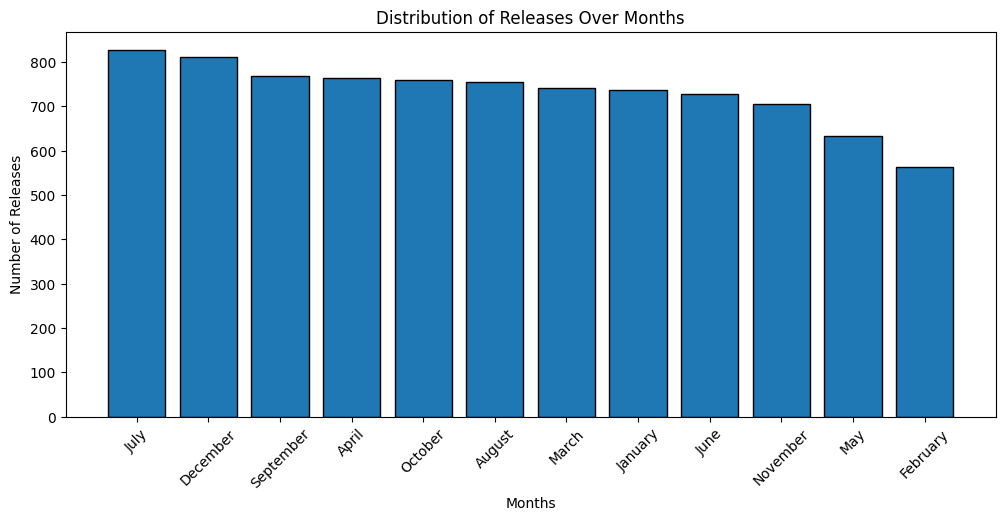

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(month_added.index, month_added.values, edgecolor="black")
plt.xticks(rotation=45)
plt.xlabel("Months")
plt.ylabel("Number of Releases")
plt.title("Distribution of Releases Over Months")
plt.show()


Streaming platforms release the most content in July and December, while February sees the fewest releases.

now lets see year trends

In [ ]:
data["year_added"].agg(["min","max"])

,year_added
min,2008
max,2021


In [ ]:
year_added=data[["title", "year_added"]].drop_duplicates()
year_added=year_added['year_added'].value_counts()
# year_added
# data["year_added"].value_counts()

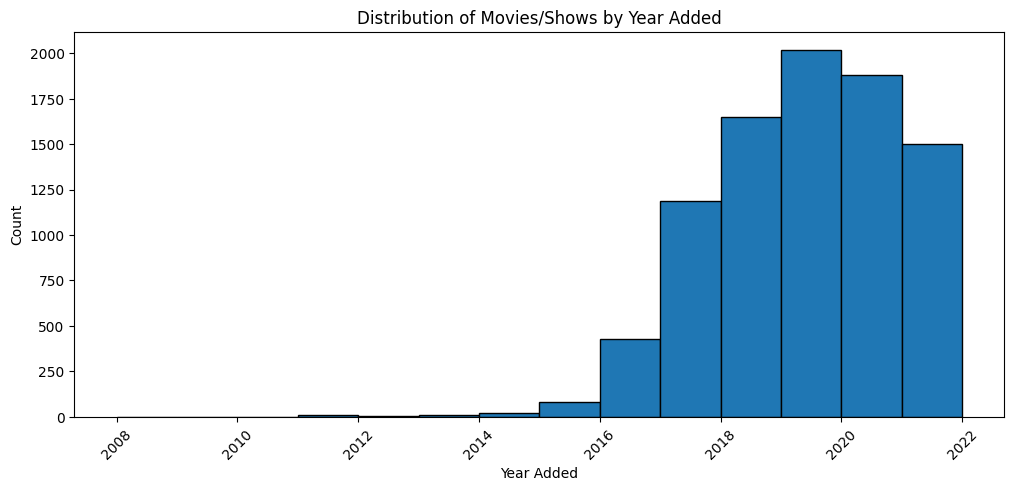

In [ ]:
data['year_added'] = pd.to_numeric(data['year_added'], errors='coerce')
year_data = data[['title', 'year_added']].drop_duplicates()

plt.figure(figsize=(12,5))
plt.hist(year_data['year_added'].dropna(),
         bins=range(int(year_data['year_added'].min()), int(year_data['year_added'].max())+2),
         edgecolor="black")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.title("Distribution of Movies/Shows by Year Added")
plt.xticks(rotation=45)
plt.show()




1. From 2008 to 2014, the number of added titles is extremely low (almost flat).

2. Major growth starts in 2015–2016.

3. Peak years: 2017–2020

    2017 → ~450

    2018 → ~1,200

    2019 → ~1,650

    2020 → ~2,000 (highest point)

4. Slight decline after 2020

    2021 → ~1,900

    2022 → ~1,500

    Possible reasons:

    Post-pandemic adjustment

    Content cuts and cost optimization by platforms

    Shift from quantity to quality




lets see the productivity of cast

In [ ]:
# Count how many unique titles each cast member has appeared in
cast_counts = data.groupby('cast')['title'].nunique().sort_values(ascending=False)
cast_counts= cast_counts.iloc[1:11]  # Top 10 actors by number of appearances


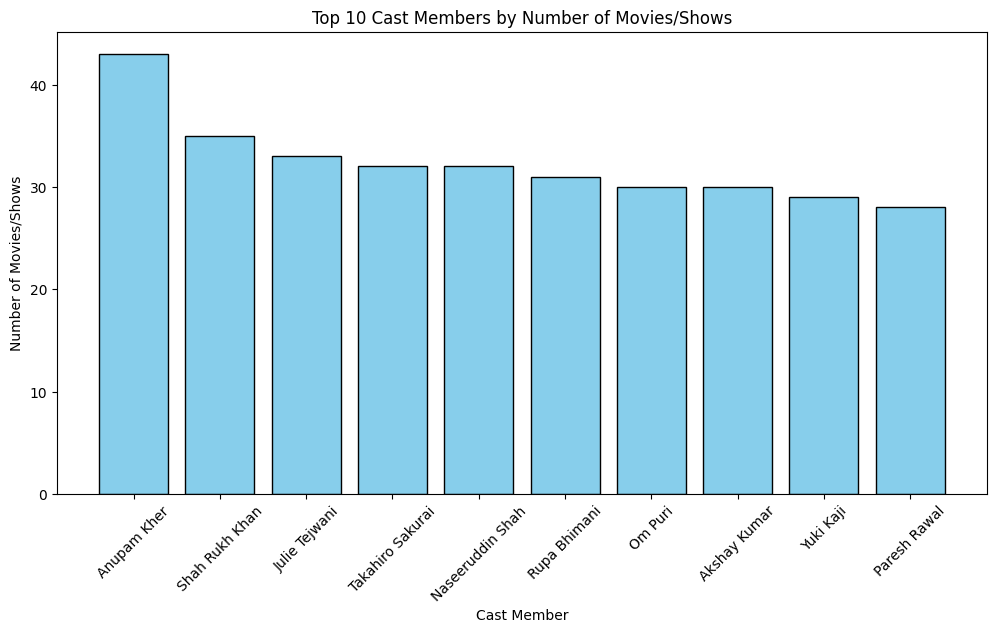

In [ ]:
import matplotlib.pyplot as plt

# Take top 10 cast members for better readability
top_cast = cast_counts.head(10)

plt.figure(figsize=(12,6))
plt.bar(x=top_cast.index, height=top_cast.values, color='skyblue', edgecolor='black')
plt.xlabel('Cast Member')
plt.ylabel('Number of Movies/Shows')
plt.title('Top 10 Cast Members by Number of Movies/Shows')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.show()


In [ ]:
country_data= data.groupby("country")["title"].nunique().sort_values(ascending=False).iloc[0:10]
# country_data

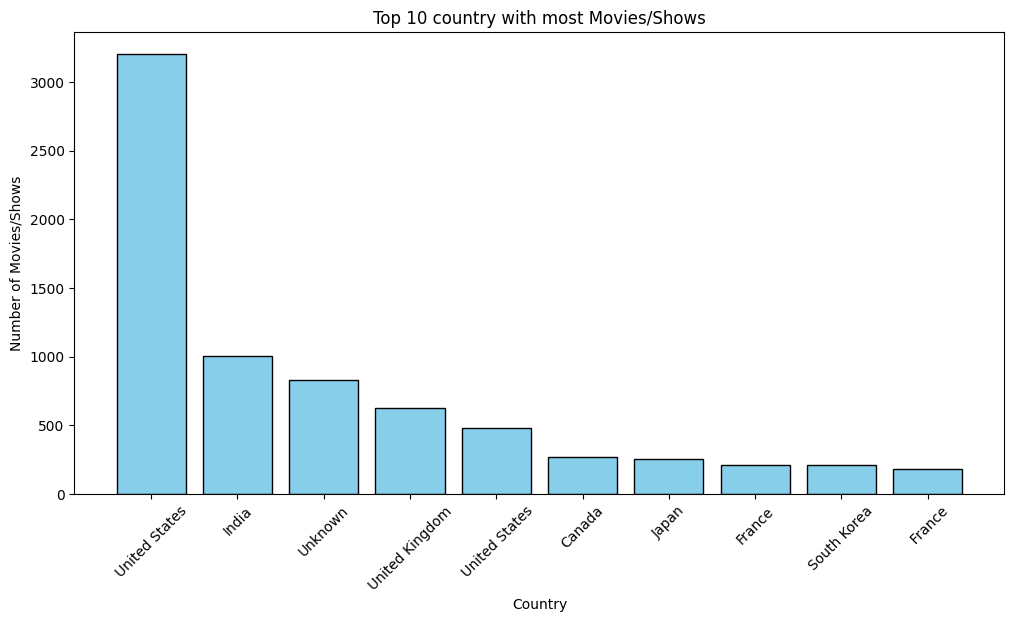

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(x=country_data.index, height=country_data.values, color='skyblue', edgecolor='black')
plt.xlabel('Country')
plt.ylabel('Number of Movies/Shows')
plt.title('Top 10 country with most Movies/Shows')
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.show()

The United States dominates with over 3200 titles, far more than any other country.
India follows with around 1000, then “Unknown,” the United Kingdom, and other countries like Canada, Japan, France, South Korea, and France

In [ ]:
rating_data= data.groupby(["rating"])["title"].nunique().sort_values(ascending=False)
# rating_data

,title
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


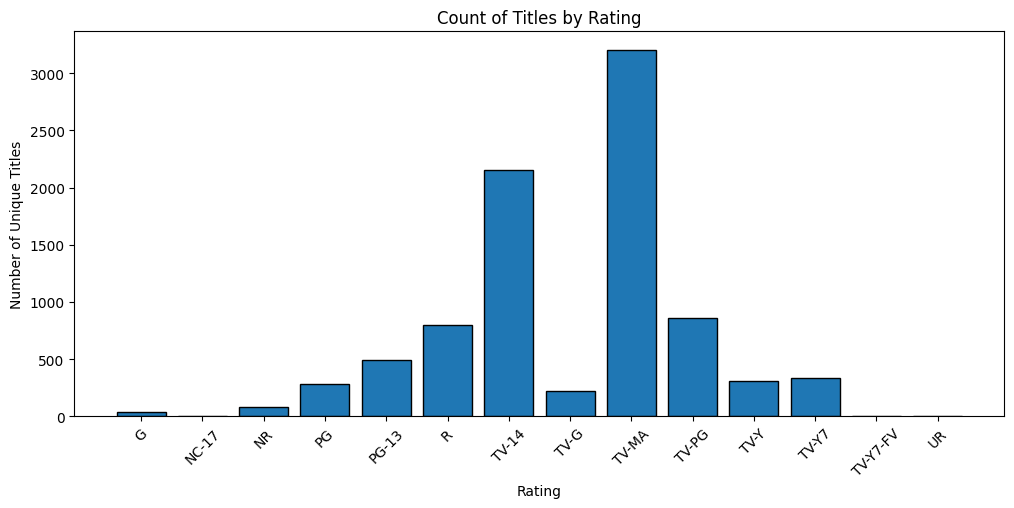

In [ ]:
rating_counts = data.groupby("rating")["title"].nunique().sort_index()

plt.figure(figsize=(12,5))
plt.bar(rating_counts.index, rating_counts.values, edgecolor="black")
plt.xlabel("Rating")
plt.ylabel("Number of Unique Titles")
plt.title("Count of Titles by Rating")
plt.xticks(rotation=45)
plt.show()


In [ ]:
listed_in= data.groupby("listed_in")["title"].nunique().sort_values(ascending=True).reset_index()
listed_in

,listed_in,title
0,TV Shows,16
1,Classic & Cult TV,26
2,Movies,53
3,Stand-Up Comedy & Talk Shows,56
4,TV Thrillers,57
5,Faith & Spirituality,65
6,Teen TV Shows,69
7,Cult Movies,71
8,Anime Features,71
9,TV Horror,75


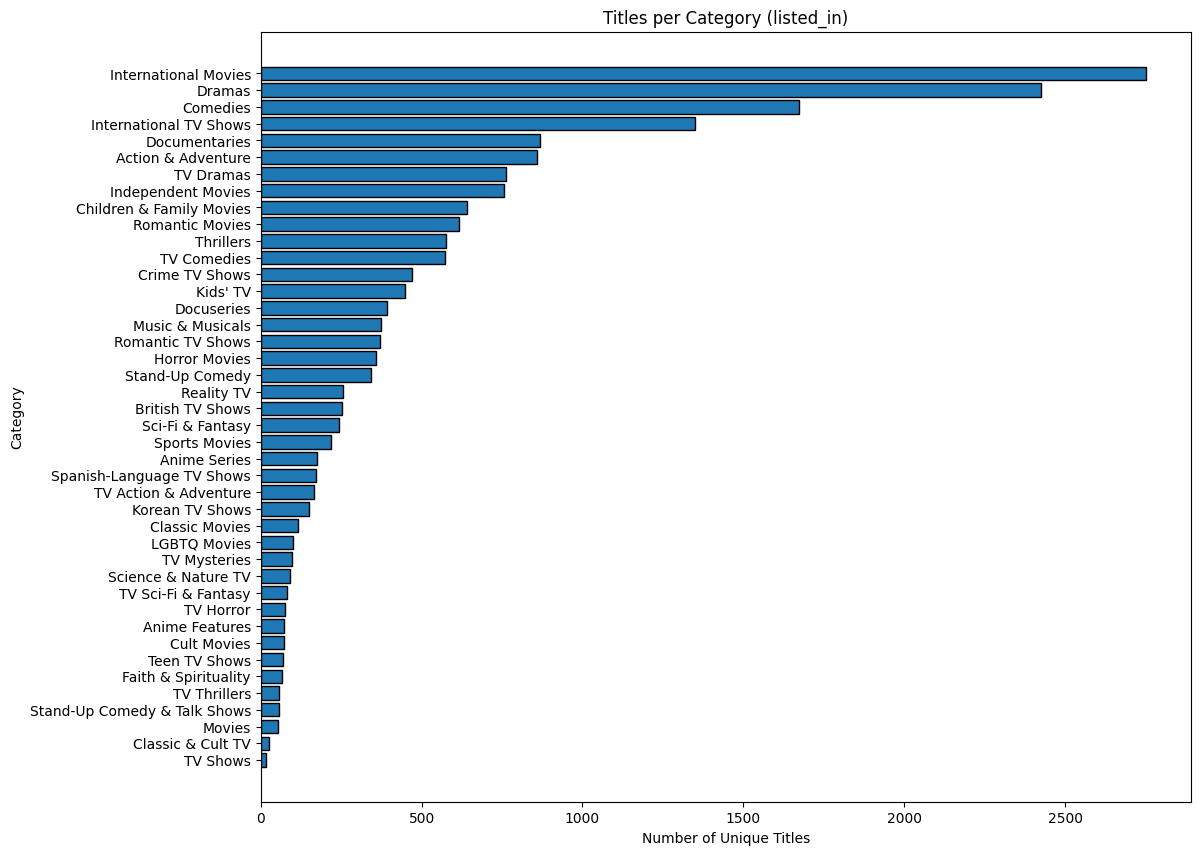

In [ ]:
plt.figure(figsize=(12,10))
plt.barh(listed_in["listed_in"], listed_in["title"], edgecolor="black")
plt.xlabel("Number of Unique Titles")
plt.ylabel("Category")
plt.title("Titles per Category (listed_in)")
plt.show()


Top categories: International Movies, Dramas, Comedies.

Medium-sized categories: Documentaries, Action & Adventure, TV Dramas.

Niche/low-count categories: Stand-Up Comedy, Faith & Spirituality, Cult Movies, Teen TV Shows.

Movies dominate top positions; TV shows mostly in lower half.

International content strong (International Movies & TV Shows).

Opportunity areas: Kids & Family, Niche genres, Anime, LGBTQ, Cult Movies.

Content strategy insight: Focus on top genres for engagement, expand niche genres for diversity.